# Arabic Transformer Features for Sentiment Classification

Built an Arabic sentiment experiment using pretrained CAMeLBERT embeddings and a supervised classification head. Reused the duplicate-cleaned split from the classical NLP benchmark for a transparent comparison. Added masked pooling, validation-based regularization, CPU quantization and explicit documentation of the distinction between frozen-feature transfer learning and end-to-end fine-tuning. The selected model achieved 71.55% held-out accuracy and 0.715 macro F1. Accuracy was 0.71 percentage points above the classical TF-IDF model on the same test set; no statistically significant advantage is claimed.

This notebook reviews saved results. The experiment script was executed separately. Enable the optional rerun only after configuring your dataset.

## Method

Replaced untrained classification-head inference with a supervised sentiment classifier over frozen CAMeLBERT dialectal-Arabic embeddings. Uses masked mean pooling, CPU int8 linear layers, a 96-token limit and validation-selected logistic-regression regularization. All classifier scaling is fitted on the training/development partition.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
root = Path.cwd()
metrics = json.loads((root / 'results' / 'metrics.json').read_text(encoding='utf8'))
if 'test_results' in metrics:
    display(pd.DataFrame(metrics['test_results']).T)
else:
    display(pd.DataFrame({'value': {k:v for k,v in metrics.items() if isinstance(v,(str,int,float))}}))

,accuracy,balanced_accuracy,macro_f1,weighted_f1,accuracy_95pct_wilson
Frozen CAMeLBERT + logistic C=0.01,0.715545,0.715883,0.715369,0.715142,"[0.7031476889768139, 0.7276257709956165]"


## Recorded environment and data provenance

In [2]:
display(metrics.get('environment', {}))
print('Data fingerprint:', metrics.get('input_sha256', metrics.get('audit',{}).get('input_sha256','see dataset checksums')))

{'python': '3.11.9',
 'numpy': '1.26.2',
 'pandas': '2.1.4',
 'sklearn': '1.3.2',
 'scipy': '1.11.4',
 'seed': 42,
 'torch': '2.2.0+cpu'}

Data fingerprint: 291f83bb268a892a108c9d313702d32213842836c8082033429b6d166060768d


## Figures

paired_comparison.png


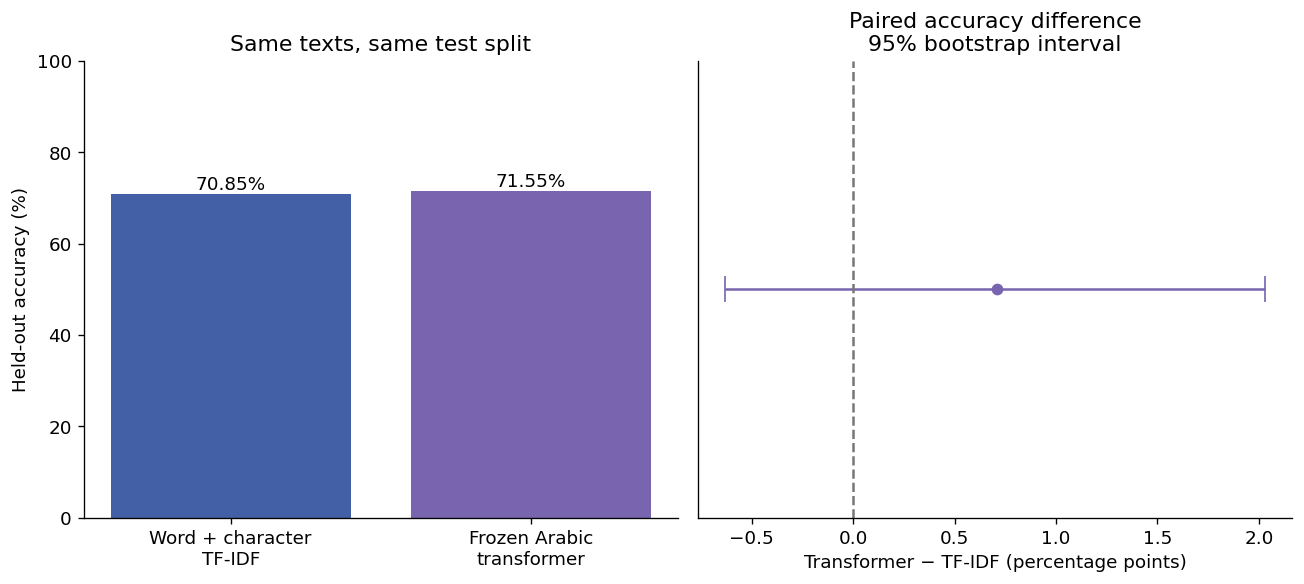

test_confusion_matrix.png


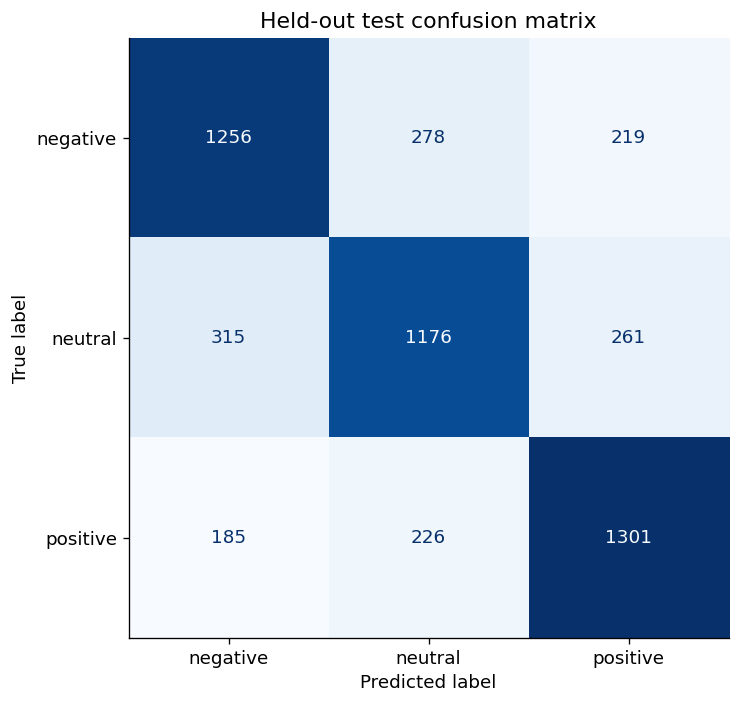

validation_comparison.png


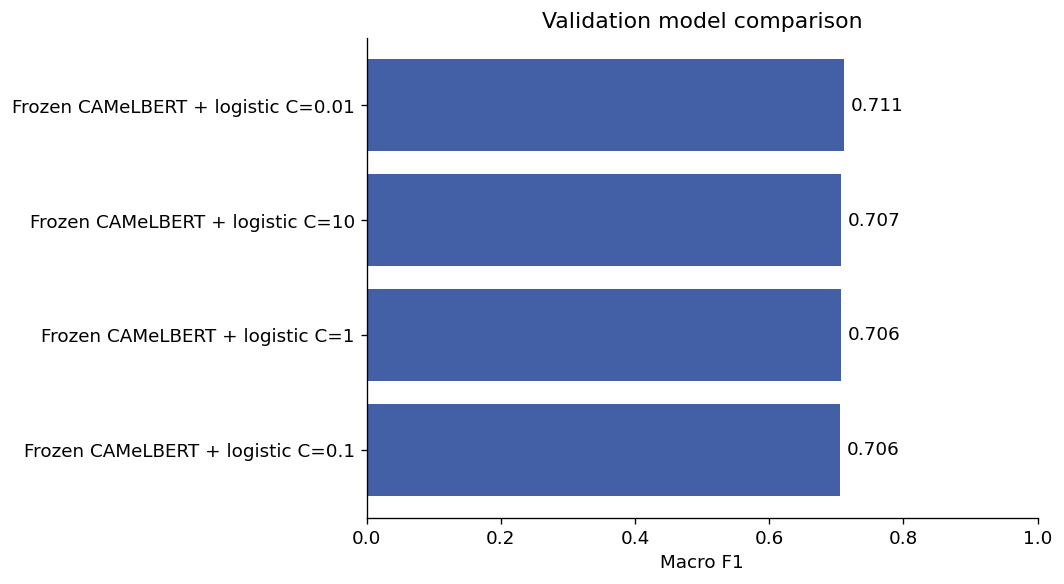

In [3]:
for figure in sorted((root / 'results').glob('*.png')):
    print(figure.name)
    display(Image(filename=str(figure)))

## Interpretation and limitations

This is a frozen encoder plus trained linear head, not end-to-end transformer fine-tuning. Pretraining-corpus overlap and dataset label provenance are unverified. The classical and transformer results use the same task and partition but different text representations. A more complex model is not automatically a stronger result.

## Optional full rerun

Adjust the dataset path in the command. This may download files or train a model and can take time. Results below are never produced from synthetic placeholder data.

In [4]:
RERUN_EXPERIMENT = False
if RERUN_EXPERIMENT:
    import subprocess, sys, shlex
    command = 'python train.py --data ../03-arabic-sentiment/data/prepared.csv --out results'
    subprocess.run([sys.executable] + shlex.split(command)[1:], cwd=root, check=True)